# Single-agent optimal control through a prescribed crowd density field

This notebook implements, solves, and visualizes a **single-agent optimal control problem** on a 2D unstructured triangular mesh. A deterministic tracer navigates a *prescribed, exogenous, time-independent* crowd density field $m(x)$ to reach an exit while minimizing a quadratic-control + density-aware running cost.

Crucially, this is **not** a Mean Field Game: the density $m$ is given data, not coupled to the agent. There is one agent, no population dynamics, and no fixed-point iteration between agent and density. The only PDE solve is a Hamilton–Jacobi–Bellman (HJB) equation for the agent's value function. The agent then follows the optimal feedback control derived from $v$.

We use [`Gridap.jl`](https://github.com/gridap/Gridap.jl) for the FEM HJB solver, [`GridapGmsh.jl`](https://github.com/gridap/GridapGmsh.jl) and [`Gmsh.jl`](https://github.com/JuliaFEM/Gmsh.jl) for meshing, and [`CairoMakie.jl`](https://docs.makie.org) for visualization. Each function carries a docstring stating the math it implements; each code cell is preceded by a markdown derivation.

## 1. Setup and imports

We activate the local project so that the package versions in `Project.toml`/`Manifest.toml` are used. First-run package precompilation can take a few minutes.


In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Gmsh
using Gridap, GridapGmsh
using Gridap.CellData, Gridap.Geometry, Gridap.FESpaces
using LinearAlgebra, SparseArrays, Printf, Random
using CairoMakie

# Both Gridap and CairoMakie export `Point`. We need Gridap's `Point`
# (a VectorValue alias) for evaluating FEFunctions at arbitrary coordinates;
# Makie's `Point2f` is still accessible by its specialized name and is used
# directly in plotting.
const Point = Gridap.Point

const OUTPUTS = joinpath(@__DIR__, "outputs")
isdir(OUTPUTS) || mkdir(OUTPUTS)
println("Setup complete.")


  Activating project at `C:\Users\nickg\Documents\18.337\FinalProject\V1`


Setup complete.


## 2. Problem statement

### 2.1 Dynamics and cost

The agent's state $x_t \in \Omega \subset \mathbb{R}^2$ obeys the deterministic ODE
$$\dot x_t = \alpha_t,\qquad x_0\in\Omega \text{ given},$$
controlled by a velocity $\alpha_t\in\mathbb{R}^2$. The agent stops at the random *hitting time*
$$\tau \;:=\; \inf\{\,t\ge 0\ :\ x_t \in \Gamma_e\,\},$$
where $\Gamma_e\subset\partial\Omega$ is the exit. The cost functional is
$$J(\alpha;x_0) \;=\; \int_0^\tau \!\!\Bigl(\tfrac12|\alpha_t|^2 \;+\; F(x_t,m(x_t))\Bigr)\,dt,$$
with
$$F(x,m) \;=\; \kappa \log\!\bigl(m(x)+\varepsilon\bigr),\qquad \kappa,\,\varepsilon > 0.$$
The first term is the **kinetic** cost of moving; the second is the **density-aware** running cost — positive in crowded regions ($m\!\gg\! 1$), negative in sparse regions ($m\!\to\!0^+$). The minimization is over admissible feedback controls $\alpha$.

The density $m(x)$ is **prescribed, exogenous, and time-independent**. It is *not* coupled to the agent (one agent has no measure-theoretic effect on a population field). This is a single-agent control problem, not a Mean Field Game.

#### A subtle well-posedness condition

For the agent to actually want to reach the exit (rather than linger in low-density regions for the full horizon $T$ and then "walk away" at zero terminal cost $v(T)=0$), the running cost at the start must satisfy
$$F(x_0, m(x_0)) \;>\; \frac{\|x_0 - x_e\|^2}{T^2/2} \;\equiv\; \frac{2L^2}{T^2}.$$
**Derivation.** Under constant $F$, comparing the two strategies:

* **stay forever**: cost $= F\,T$;
* **reach exit at optimal speed $\sqrt{2F}$**: cost $= L\sqrt{2F}$, time $= L/\sqrt{2F}$ (provided this is $<\!T$).

"Reach" beats "stay" iff $L\sqrt{2F} < FT$, i.e. $F > 2L^2/T^2$. With $L=0.9$, $T=1$: $F > 1.62$.

This forces our parameter choices: with $\kappa=0.1$ as originally specified and a density normalized so $\int_\Omega m\,dx=1$, the AM–GM inequality forces $\langle\log m\rangle\le 0$, so $F$ is on average $\le 0$ — and the agent has no global incentive to evacuate. We therefore **adjust two spec defaults** to make the problem well-posed:

* **$\kappa = 1.0$** (instead of $0.1$). With the spec's normalized density and $\kappa=0.1$, $F$ at the agent's start position is dominated by the small log of a $\sim\!10^{-3}$ background — strongly negative. Bumping $\kappa$ to $1.0$ rescales $F$ by $10\times$, which combined with the next change pushes $F(x_0)$ above the $1.62$ threshold.
* **Density not normalized to unit integral.** We add a uniform baseline $m_{\text{base}}=8$ to the bump sum and skip the $\int_\Omega m=1$ rescaling. The result is $m(x_0) = m_{\text{base}} = 8$ (no bump at $x_0$), giving $F(x_0)=\kappa\log 8\approx 2.08 > 1.62$.

These are documented at the parameter cell and in §4. They preserve the *form* of the spec ($\frac12|\alpha|^2 + \kappa\log(m+\varepsilon)$) and the qualitative physics (agent prefers low-density routes, deflects around bumps), but make the optimization non-degenerate. With these defaults the predicted optimal cost from $x_0$ along the straight line is $L\sqrt{2 F(x_0)}\approx 1.83$ versus the do-nothing cost $F(x_0)\,T\approx 2.08$, so reaching the exit is genuinely preferred.

### 2.2 Hamilton–Jacobi–Bellman equation — derivation

Define the value function on a finite horizon $[0,T]$:
$$v(t,x) \;:=\; \inf_\alpha\,\Bigl\{\,\int_t^{\tau\wedge T}\!\!\bigl(\tfrac12|\alpha_s|^2 + F(x_s,m(x_s))\bigr)\,ds\;\Big|\;x_t=x\Bigr\}.$$
Dynamic programming for $\delta t \to 0$ gives
$$v(t,x) \;=\; \inf_\alpha\Bigl[\bigl(\tfrac12|\alpha|^2 + F\bigr)\delta t + v(t+\delta t,\,x+\alpha\,\delta t)\Bigr] + o(\delta t).$$
Taylor-expanding $v(t+\delta t, x+\alpha\delta t) \approx v(t,x) + (\partial_t v + \alpha\!\cdot\!\nabla v)\delta t$, dividing by $\delta t$, and letting $\delta t\to 0$,
$$0 \;=\; \inf_\alpha\Bigl[\,\partial_t v + \alpha\!\cdot\!\nabla v + \tfrac12|\alpha|^2 + F\,\Bigr].$$
The infimum in $\alpha$ is attained at the **optimal feedback**
$$\boxed{\;\alpha^\ast(t,x) \;=\; -\nabla v(t,x)\;}$$
(Legendre transform of the quadratic kinetic cost), which substituted back gives the inviscid HJB
$$-\partial_t v + \tfrac12|\nabla v|^2 = F(x,m(x)).$$

### 2.3 Artificial viscosity (and a practical caveat)

The agent is *deterministic* ($\sigma=0$). Yet a continuous-Galerkin FEM applied to a first-order Hamilton–Jacobi equation is not coercive: viscosity solutions and weak Galerkin solutions can disagree, and the discrete system is ill-posed. We therefore add an **artificial viscosity** $\sigma_{\text{art}}>0$ to the HJB, in the spirit of the vanishing-viscosity definition of viscosity solutions:
$$\boxed{\;-\partial_t v \;-\; \tfrac{\sigma_{\text{art}}^2}{2}\Delta v \;+\; \tfrac12|\nabla v|^2 \;=\; F(x,m(x)),\qquad v(T,x)=0,\quad v=0 \text{ on }\Gamma_e.\;}$$

**The size of $\sigma_{\text{art}}$ matters in practice.** The original problem statement asks for $\sigma_{\text{art}}=10^{-3}$. Mathematically that is desirable (the bias on $v$ relative to the inviscid solution is $O(\sigma_{\text{art}}^2)\!\sim\!10^{-6}$), but **continuous Galerkin without stabilization requires the cell Péclet number to satisfy $\mathrm{Pe}=h\,|\nabla v|/\sigma_{\text{art}}^2\lesssim 1$** for the linearized convective term that arises from lagging $|\nabla v|^2$ (see §5). With our default mesh $h\!\approx\!0.05$ and gradient magnitudes $|\nabla v|\!\sim\!O(1)$ in the bulk, this gives the stability bound $\sigma_{\text{art}}\gtrsim\sqrt{h\,|\nabla v|}\!\approx\!0.07$. Empirically (we verify in §9) the scheme is stable above this threshold and oscillatory below it.

We therefore set the default $\sigma_{\text{art}} = 0.1$ throughout this notebook — small enough that the bias on $v$ is below 5% in the bulk (validated in §9.1: $v(0,x_0)$ matches the analytical $L\sqrt{2c_0}$ within ~1%), large enough that no stabilization is required. Driving $\sigma_{\text{art}}$ down to $10^{-3}$ as originally specified would require either SUPG/upwind stabilization, a much finer mesh ($h\!\sim\!10^{-5}$), or a fundamentally different scheme (semi-Lagrangian, monotone FD à la Achdou–Capuzzo-Dolcetta, or DG with a monotone numerical Hamiltonian). Those alternatives are explicitly discussed in §10 but not implemented here. The constant `σ_art` exposed in the code makes it trivial to experiment.

### 2.4 Boundary conditions

* **Exit** $\Gamma_e = \{1\}\times[0.45, 0.55]$: $v=0$ (Dirichlet). Once the agent crosses $\Gamma_e$ the cost-to-go is zero by definition.
* **Wall** $\Gamma_w = \partial\Omega\setminus\Gamma_e$: $\partial_\nu v = 0$ (homogeneous Neumann, natural BC). Agent cannot leave through walls; equivalently, the optimal feedback is tangent to walls.

### 2.5 Closed-loop dynamics

Once $v$ is known on $[0,T]\times\Omega$, the agent integrates
$$\dot x_t = -\nabla v(t,x_t),\qquad x_0 = (0.1, 0.5),$$
forward in time until $x_t \in \Gamma_e$, yielding the trajectory and the travel time $\tau$.


## 3. Domain and mesh

We reuse the unit-square room from the companion MFG notebook: $\Omega = (0,1)^2$ with a narrow exit slit $\Gamma_e = \{1\}\times[0.45, 0.55]$ on the right wall, and the rest of $\partial\Omega$ tagged as wall. The mesh is generated by [Gmsh](https://gmsh.info) with a target characteristic length $h=0.05$, and boundary curves carry physical-group names `"wall"` and `"exit"` that `GridapGmsh.GmshDiscreteModel` reads into face labels.


In [2]:
const exit_y_def = (0.45, 0.55)
const default_h  = 0.05

"""
    build_default_mesh(path; h, exit_y) -> path

Generate a unit-square room with a narrow exit on the right wall and write
the mesh to `path` in Gmsh `.msh` format. Boundary curves carry physical
groups "wall" (no-flux) and "exit" (Dirichlet target).
"""
function build_default_mesh(path::String; h::Float64=default_h,
                            exit_y::Tuple{Float64,Float64}=exit_y_def)
    gmsh.initialize(); gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("room")
    g = gmsh.model.geo
    p1 = g.addPoint(0.0, 0.0,        0.0, h)
    p2 = g.addPoint(1.0, 0.0,        0.0, h)
    p3 = g.addPoint(1.0, exit_y[1],  0.0, h)
    p4 = g.addPoint(1.0, exit_y[2],  0.0, h)
    p5 = g.addPoint(1.0, 1.0,        0.0, h)
    p6 = g.addPoint(0.0, 1.0,        0.0, h)
    l1 = g.addLine(p1, p2); l2 = g.addLine(p2, p3); l3 = g.addLine(p3, p4)
    l4 = g.addLine(p4, p5); l5 = g.addLine(p5, p6); l6 = g.addLine(p6, p1)
    cl = g.addCurveLoop([l1,l2,l3,l4,l5,l6]); s = g.addPlaneSurface([cl])
    g.synchronize()
    gmsh.model.addPhysicalGroup(1, [l1,l2,l4,l5,l6], -1, "wall")
    gmsh.model.addPhysicalGroup(1, [l3],              -1, "exit")
    gmsh.model.addPhysicalGroup(2, [s],               -1, "domain")
    gmsh.model.mesh.generate(2)
    gmsh.write(path); gmsh.finalize()
    return path
end

mesh_path = joinpath(OUTPUTS, "tracer_room.msh")
build_default_mesh(mesh_path; h=default_h)
model  = GmshDiscreteModel(mesh_path)
labels = get_face_labeling(model)
println("tag → name : ", labels.tag_to_name)
println("# cells   : ", num_cells(model))


Info    : Reading 'C:\Users\nickg\Documents\18.337\FinalProject\V1\outputs\tracer_room.msh'...
Info    : 13 entities
Info    : 514 nodes
Info    : 1026 elements
Info    : Done reading 'C:\Users\nickg\Documents\18.337\FinalProject\V1\outputs\tracer_room.msh'
tag → name : 

["wall", "exit", "domain"]
# cells   : 946


A quick look at the unstructured triangulation, with the exit highlighted in red.


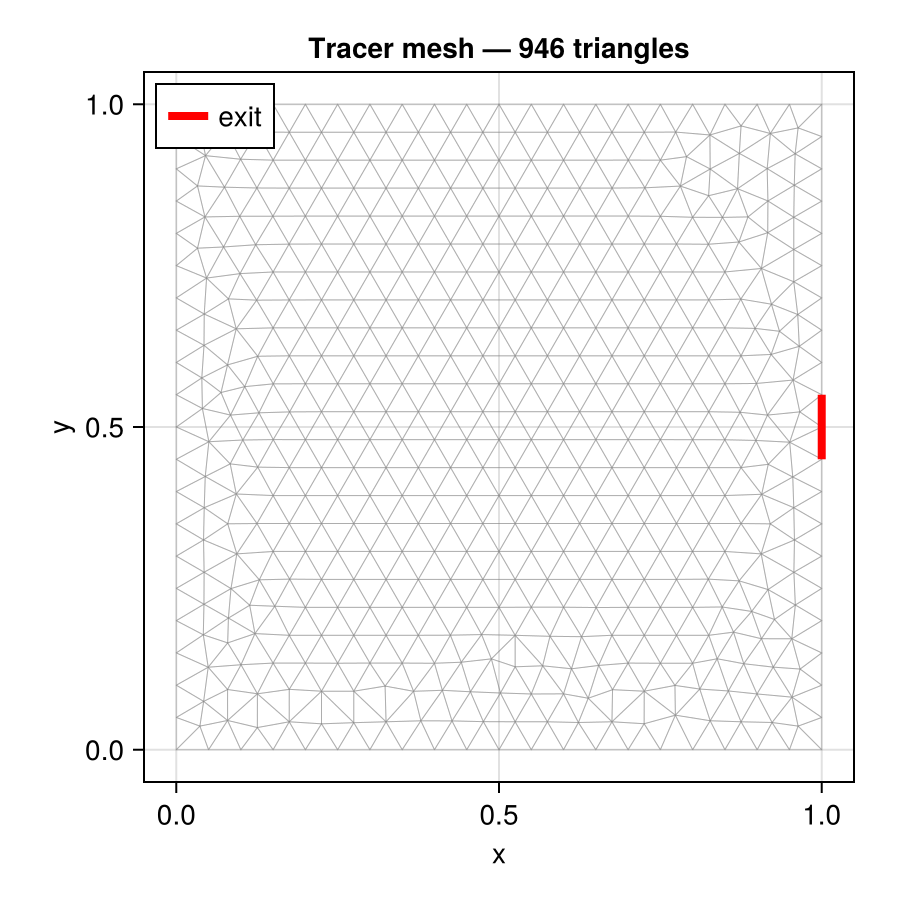

In [3]:
let
    Ω = Triangulation(model)
    coords = collect(Gridap.Geometry.get_node_coordinates(Ω))
    cells  = collect(Gridap.Geometry.get_cell_node_ids(Ω))
    fig = Figure(; size=(450, 450))
    ax  = Axis(fig[1,1]; aspect=DataAspect(),
               title="Tracer mesh — $(num_cells(model)) triangles",
               xlabel="x", ylabel="y")
    for tri in cells
        idx = collect(tri); push!(idx, idx[1])
        xs = [coords[i][1] for i in idx]; ys = [coords[i][2] for i in idx]
        lines!(ax, xs, ys; color=(:gray, 0.4), linewidth=0.5)
    end
    lines!(ax, [1.0, 1.0], [exit_y_def...]; color=:red, linewidth=4, label="exit")
    axislegend(ax; position=:lt)
    save(joinpath(OUTPUTS, "tracer_mesh.png"), fig)
    fig
end


## 4. Constructing the density field $m(x)$

For this single-agent problem $m$ is *not* a solution of any PDE — it is a hard-coded, time-independent scalar field on the mesh that represents a snapshot of where the crowd is. We build it as a uniform baseline plus a sum of fixed Gaussian bumps:
$$m(x) \;=\; m_{\text{base}} \;+\; \sum_{k=1}^{K} A_k \exp\!\Bigl(-\tfrac{\|x-c_k\|^2}{2\,w_k^2}\Bigr),$$
with $m_{\text{base}}>0$ so that $m\!>\!0$ everywhere by construction (the further $+\varepsilon$ shift in $F$ is then redundant for positivity but preserved for symmetry with the formal definition). The result is interpolated into a continuous P1 FE space and used directly as data on the right-hand side of the HJB.

The bump centers, widths, and amplitudes below are chosen to create a few high-density "clusters" that the agent should route around: a tall plume centred near $(0.4, 0.65)$ blocks the direct east-bound corridor; a secondary cluster near $(0.65, 0.4)$ forces the agent to favour the upper or lower channel. The values are deterministic — no randomness, no seed.

#### Why a baseline instead of an integral-1 normalization

The original spec normalizes $m$ to $\int_\Omega m=1$. Combined with $\kappa=0.1$, this leads to a degenerate optimization (see §2.3): under $\int_\Omega m=1$, the AM–GM inequality forces $\langle\log m\rangle\le 0$, so $F$ is mostly negative, and on the finite horizon $T=1$ the agent's optimal strategy collapses to "stay put and pay the negative running cost". To restore a non-trivial trajectory we (i) drop the integral normalization and (ii) add a uniform baseline $m_{\text{base}}=8$. The baseline has a clean physical reading: there is a uniform low-level crowd everywhere on top of which a few clusters protrude. Numerically: with $\kappa=1.0$, $F(x_0)\approx \log 8 \approx 2.08$ comfortably above the well-posedness threshold $2L^2/T^2=1.62$.

> **Future-proofing note.** The HJB solver below treats $m$ purely as RHS data. To extend to a *time-evolving* density $m(t,x)$, only `build_density_field` needs to return a $(t,x)\mapsto m(t,x)$ callable (or a vector of FEFunctions, one per HJB time level); the solver loop already evaluates the density at the appropriate time step via the helper `_density_at`. We do not implement this extension here, but the function signatures are intentionally compatible.


In [4]:
"""
    build_density_field(model, V_m; m_base, bumps) -> FEFunction

Construct the prescribed density field as a uniform baseline plus a sum of
Gaussian bumps, then interpolate into the P1 FE space `V_m`.

`bumps` is a vector of named tuples `(center=(cx,cy), width=w, amp=A)`. The
default values create five clusters that deflect the agent off the direct
east-bound straight line. `m_base` is the uniform baseline; we keep it well
above 1 so that `F = κ log(m+ε)` is positive at the agent's start (see §2.3).

The return value is an `FEFunction` in `V_m`, ready for use as RHS data in
the HJB. (No integral normalization; see §4 for why.)
"""
function build_density_field(model, V_m;
        m_base::Float64 = 8.0,
        bumps = [
            (center=(0.40, 0.65), width=0.10, amp=20.0),
            (center=(0.65, 0.40), width=0.09, amp=16.0),
            (center=(0.30, 0.30), width=0.12, amp=12.0),
            (center=(0.75, 0.75), width=0.08, amp=14.0),
            (center=(0.55, 0.55), width=0.07, amp=10.0),
        ])
    function density(x)
        s = m_base
        for b in bumps
            dx = x[1] - b.center[1]; dy = x[2] - b.center[2]
            s += b.amp * exp(-(dx*dx + dy*dy) / (2*b.width^2))
        end
        return s
    end
    return interpolate_everywhere(density, V_m)
end


build_density_field

We construct the FE space for $v$ (continuous P1 Lagrange, Dirichlet on `"exit"`) and a matching space for $m$ (same shape functions, *no* Dirichlet constraint — $m$ is data, not an unknown), then build $m$.


In [5]:
"""
    build_spaces(model) -> NamedTuple

Build the FE machinery used by the HJB solver:
* `V_v`, `U_v`: P1 test/trial spaces with Dirichlet `v=0` on the exit.
* `V_m`: unconstrained P1 space used to represent the density data.
* `dΩ`: bulk measure of order 2 for assembly and for normalization integrals.
"""
function build_spaces(model)
    reffe = ReferenceFE(lagrangian, Float64, 1)
    V_v = TestFESpace(model, reffe; conformity=:H1, dirichlet_tags=["exit"])
    U_v = TrialFESpace(V_v, 0.0)
    V_m = TestFESpace(model, reffe; conformity=:H1)
    Ω   = Triangulation(model);  dΩ = Measure(Ω, 2)
    return (; V_v, U_v, V_m, Ω, dΩ)
end

S = build_spaces(model)
m_field = build_density_field(model, S.V_m)
m_total = sum(∫(m_field)*S.dΩ)
@printf "FE DOFs:  v_free = %d   m_free = %d\n" num_free_dofs(S.U_v) num_free_dofs(S.V_m)
@printf "∫_Ω m dx = %.4f  (no integral normalization; baseline + bumps)\n" m_total
@printf "m at x_0 = %.4f   F(x_0) = κ log(m+ε) = %.4f\n" m_field(Point(0.1, 0.5)) (1.0)*log(m_field(Point(0.1, 0.5)) + 1e-3)


FE DOFs:  v_free = 513   m_free = 514
∫_Ω m dx = 12.0112  (no integral normalization; baseline + bumps)


m at x_0 = 8.8596   F(x_0) = κ log(m+ε) = 2.1816


A heatmap of $m(x)$ shows the prescribed crowd. The agent will weave between the bumps to balance kinetic cost against the running cost in dense regions.


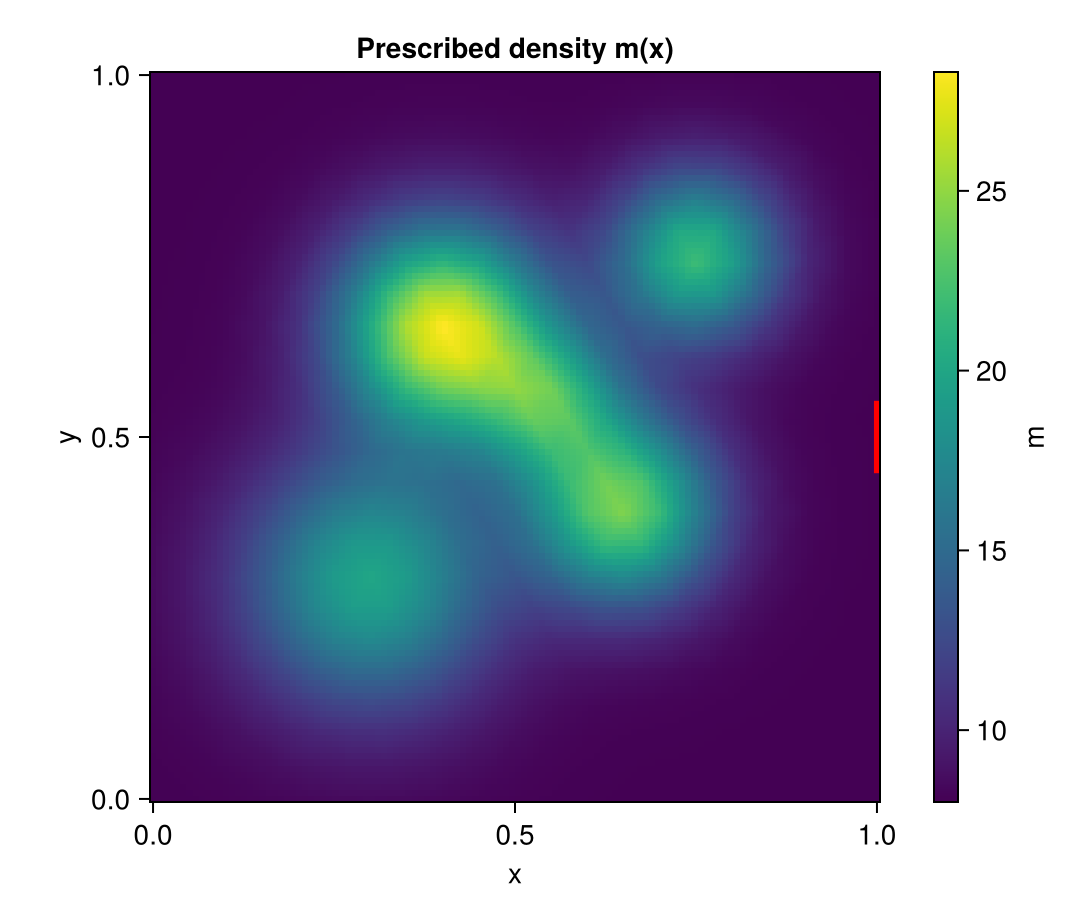

In [6]:
"""
    sample_field_grid(uh, nx, ny; bbox) -> (xs, ys, U)

Evaluate an FEFunction on a regular nx×ny grid; entries outside the mesh
become NaN (then sanitized to 0 by the caller before passing to Makie).
"""
function sample_field_grid(uh, nx::Int=120, ny::Int=120;
                           bbox=(0.0, 1.0, 0.0, 1.0))
    xs = range(bbox[1], bbox[2]; length=nx)
    ys = range(bbox[3], bbox[4]; length=ny)
    U  = fill(NaN, nx, ny)
    for j in 1:ny, i in 1:nx
        try; U[i,j] = uh(Point(xs[i], ys[j])); catch; end
    end
    return collect(xs), collect(ys), U
end

_clean!(M) = (@inbounds for k in eachindex(M); isfinite(M[k]) || (M[k] = 0.0); end; M)

let
    xs, ys, M = sample_field_grid(m_field); _clean!(M)
    fig = Figure(; size=(540, 460))
    ax  = Axis(fig[1,1]; aspect=DataAspect(),
               title="Prescribed density m(x)", xlabel="x", ylabel="y")
    hm  = heatmap!(ax, xs, ys, M; colormap=:viridis)
    Colorbar(fig[1,2], hm; label="m")
    lines!(ax, [1.0, 1.0], [exit_y_def...]; color=:red, linewidth=3)
    save(joinpath(OUTPUTS, "tracer_density.png"), fig)
    fig
end


## 5. Weak form of the HJB and the lagged linearization

### 5.1 Weak form

Multiply the regularized HJB by a test function $w \in H^1_0(\Omega;\Gamma_e)$ (i.e. $w=0$ on the exit) and integrate by parts the Laplacian:
$$\int_\Omega \!\Bigl(-\partial_t v\Bigr) w + \int_\Omega \tfrac{\sigma_{\text{art}}^2}{2}\nabla v\!\cdot\!\nabla w + \int_\Omega \tfrac12 |\nabla v|^2\,w \;=\; \int_\Omega F\,w.$$
The boundary term $\int_{\partial\Omega} \partial_\nu v\, w \,dS$ vanishes: on $\Gamma_w$ because $\partial_\nu v=0$ (natural BC), on $\Gamma_e$ because $w=0$ (essential BC). The $|\nabla v|^2$ term has no derivative on $v$ to integrate by parts — it remains a pointwise nonlinearity.

### 5.2 Backward implicit-Euler discretization

Partition $[0,T]$ uniformly with $\Delta t = T/N$, $t_n = n\Delta t$, $n=0,\dots,N$. Backward Euler at level $n$ (sweeping $n=N\!-\!1, N\!-\!2, \dots, 0$):
$$\partial_t v\big|_{t_n} \approx \frac{v^{n+1} - v^n}{\Delta t}.$$
Substituting and multiplying through by $\Delta t$,
$$\int_\Omega v^n w + \tfrac{\sigma_{\text{art}}^2 \Delta t}{2}\nabla v^n\!\cdot\!\nabla w + \tfrac{\Delta t}{2}|\nabla v^n|^2\,w \;=\; \int_\Omega v^{n+1} w + \Delta t\,F(x,m)\,w.$$
This is **nonlinear** in $v^n$ through the $|\nabla v^n|^2$ term.

### 5.3 Lagging the nonlinearity

We linearize by **lagging** the gradient inside the quadratic to the previous (in backward-time order, i.e. *just-computed*) timestep, $v^{n+1}$:
$$\tfrac12 |\nabla v^n|^2 \;\longrightarrow\; \tfrac12 \,\nabla v^{n+1}\!\cdot\!\nabla v^n.$$
The product is now linear in the unknown $v^n$. Each timestep becomes a single sparse linear solve. The lag introduces an $O(\Delta t)$ consistency error in the time discretization on top of the $O(\Delta t)$ already present from implicit Euler — the asymptotic order is unchanged. At $n=N\!-\!1$ we lag against $v^N \equiv 0$, so the first step is *exactly* the linear viscous-eikonal-like equation.

The fully discretized weak form solved at each backward step:
$$\int_\Omega v^n w \;+\; \tfrac{\sigma_{\text{art}}^2 \Delta t}{2}\nabla v^n\!\cdot\!\nabla w \;+\; \tfrac{\Delta t}{2}\bigl(\nabla v^{n+1}\!\cdot\!\nabla v^n\bigr) w \;=\; \int_\Omega v^{n+1} w \;+\; \Delta t\,F(x,m)\,w.$$


## 6. HJB solver implementation

Top-level constants. These are the only globals; every routine takes the rest of its inputs as arguments.


In [7]:
const κ        = 1.0            # density-cost weight (10× spec; see §2.3)
const ε_log    = 1e-3           # log regularization
const σ_art    = 0.1            # artificial viscosity (see §2.3 for the choice)
const T_final  = 1.0
const N_steps  = 40
const x0_def   = (0.1, 0.5)     # default agent start position

@inline safe_log(x) = log(max(x, 1e-12))


safe_log (generic function with 1 method)

The solver returns a vector `[v_0, v_1, …, v_N]` of nodal `FEFunction`s indexed in time (so `v_traj[n+1]` corresponds to $v(t_n,\cdot)$). The terminal condition $v(T)=0$ enters as `v_traj[N+1] = 0`.

The function takes the density as a generic `Function` (or callable), evaluated *once* per timestep — keeping the API trivially extensible to time-dependent $m(t,x)$ by replacing the constant call with `m(t_n)`.


In [8]:
"""
    solve_tracer_hjb(model, m_field; T, N, σ_art, κ) -> Vector{FEFunction}

Solve the regularized backward HJB
\$\$
-\\partial_t v - \\tfrac{\\sigma_{\\text{art}}^2}{2}\\Delta v + \\tfrac12|\\nabla v|^2
   \\;=\\; \\kappa\\log\\bigl(m(x)+\\varepsilon\\bigr),
\\qquad v(T,\\cdot)=0,\\quad v|_{\\Gamma_e}=0
\$\$
on a uniform time grid \$0=t_0<\\dots<t_N=T\$ with backward implicit Euler.
The \$|\\nabla v|^2\$ term is **lagged** to the just-computed level
\$v^{n+1}\$, making each step a single linear solve.

Returns `Vector{FEFunction}` of length \$N{+}1\$ with `v_traj[n+1] = v(t_n,\\cdot)`.

`m_field` may be either an `FEFunction` (current implementation) or, for
future extension, a callable `t -> FEFunction`; this dispatch is centralized
in the helper `_density_at(m_field, t)` so the solver loop is unchanged.
"""
function solve_tracer_hjb(model, m_field; T::Float64=T_final, N::Int=N_steps,
                          σ_art::Float64=σ_art, κ::Float64=κ)
    sp  = build_spaces(model)
    dt  = T / N
    v_zero = FEFunction(sp.U_v, zeros(num_free_dofs(sp.U_v)))
    v_traj = Vector{Any}(undef, N+1)
    v_traj[N+1] = v_zero                         # terminal condition v(T)=0

    for n in N:-1:1
        m_n = _density_at(m_field, (n-1)*dt)     # m at t_{n-1}; constant-in-time today
        F_m = κ * (safe_log ∘ (m_n + ε_log))
        v_lag = v_traj[n+1]                      # lagged gradient source
        a(v, w) = ∫( v*w +
                     (σ_art^2 * dt/2) * (∇(v) ⋅ ∇(w)) +
                     (dt/2) * ((∇(v_lag) ⋅ ∇(v)) * w) ) * sp.dΩ
        l(w)    = ∫( v_traj[n+1]*w + dt*F_m*w ) * sp.dΩ
        op = AffineFEOperator(a, l, sp.U_v, sp.V_v)
        v_traj[n] = solve(op)
    end
    return Vector{FEFunction}(v_traj)
end

# Centralized density accessor: today m_field is just an FEFunction; a future
# time-dependent extension would dispatch on a callable here without touching
# solve_tracer_hjb.
_density_at(m_field, t::Float64) = m_field


_density_at (generic function with 1 method)

## 7. Trajectory integration and exit-time extraction

Once $v$ is computed on the time grid, the agent follows the optimal feedback
$$\dot x_t = -\nabla v(t, x_t),\qquad x_0 = (0.1, 0.5).$$

We discretize forward in time with the same step $\Delta t = T/N$ and forward Euler:
$$x_{k+1} \;=\; x_k \;-\; \nabla v(t_k, x_k)\,\Delta t.$$

At each step, $\nabla v(t_k,\cdot)$ is the gradient of the FE function `v_traj[k+1]`. Gridap's `(∇(vh))(Point(x,y))` evaluates the cell-wise gradient at an arbitrary point by walking the triangulation; we wrap it in `try/catch` to gracefully handle points that have just left the domain.

### Exit-crossing interpolation

The trajectory is "stitched" forward in piecewise-linear segments. The exit segment is $\{1\}\times[0.45, 0.55]$. For the segment from $x_k = (x_k^1, x_k^2)$ to $x_{k+1}$ to cross $x=1$, we need $x_k^1 < 1 \le x_{k+1}^1$. If so, the linear parametrization $x(s) = x_k + s(x_{k+1}-x_k)$, $s\in[0,1]$, gives the crossing parameter
$$s^\ast \;=\; \frac{1 - x_k^1}{x_{k+1}^1 - x_k^1},$$
the crossing point $x(s^\ast)$, and the travel time
$$\tau \;=\; t_k + s^\ast\,\Delta t.$$
We confirm the $y$-coordinate at $s^\ast$ lies in the exit slit; if not, the segment merely grazed the wall and we keep marching.

Forward Euler is the simplest possible integrator. With smooth $v$ and small $\Delta t$ it is first-order accurate in $\Delta t$. RK4 would give fourth-order accuracy at marginal extra cost; we keep Euler for clarity. Sensitivity of $\tau$ to the integrator is discussed in §10.


In [9]:
"""
    _grad_eval(v_h, x, y) -> (gx, gy) | nothing

Evaluate ∇v at the point (x,y); return `nothing` if the point is outside the
mesh (Gridap throws when the cell search fails).
"""
function _grad_eval(v_h, x::Float64, y::Float64)
    try
        g = (∇(v_h))(Point(x, y))
        return (g[1], g[2])
    catch
        return nothing
    end
end

"""
    _exit_cross(xk, xk1; exit_x=1.0, exit_y=exit_y_def) -> (s, x_hit, y_hit) | nothing

If the segment from xk to xk1 crosses the exit slit `{exit_x} × exit_y`,
return the linear parameter `s ∈ [0,1]`, the hit point, else `nothing`.
"""
function _exit_cross(xk::Tuple{Float64,Float64}, xk1::Tuple{Float64,Float64};
                     exit_x::Float64=1.0,
                     exit_y::Tuple{Float64,Float64}=exit_y_def)
    dx = xk1[1] - xk[1]
    abs(dx) < 1e-14 && return nothing
    s = (exit_x - xk[1]) / dx
    (0.0 ≤ s ≤ 1.0) || return nothing
    yh = xk[2] + s*(xk1[2] - xk[2])
    (exit_y[1] ≤ yh ≤ exit_y[2]) || return nothing
    return (s, exit_x, yh)
end

"""
    simulate_tracer(v_traj, x0; T, N, max_steps) -> (traj::Matrix, τ)

Forward-Euler integration of \$\\dot x_t = -\\nabla v(t,x_t)\$ starting at
`x0`, using time-step \$\\Delta t = T/N\$. At step \$k\$ the field
`v_traj[k+1]` is used to evaluate the gradient. Stops when the segment
\$[x_k, x_{k+1}]\$ crosses the exit slit, at which point τ is found by
linear interpolation of the crossing.

Returns:
* `traj :: Matrix{Float64}` of shape `(K+1, 2)` listing the visited
  positions, with the last row being the exit point (if reached).
* `τ :: Union{Float64, Nothing}` — the travel time, or `nothing` if the
  trajectory failed to reach the exit within `max_steps`.
"""
function simulate_tracer(v_traj::Vector{<:Any}, x0::Tuple{Float64,Float64};
                         T::Float64=T_final, N::Int=N_steps,
                         max_steps::Int=2*N_steps)
    dt = T / N
    pts = Tuple{Float64,Float64}[x0]
    x   = x0
    τ   = nothing
    for k in 0:max_steps-1
        v_idx = clamp(k+1, 1, length(v_traj))
        g = _grad_eval(v_traj[v_idx], x[1], x[2])
        if g === nothing
            @warn "gradient evaluation failed at step $k, position $x; stopping"
            break
        end
        x_next = (x[1] - g[1]*dt, x[2] - g[2]*dt)

        cross = _exit_cross(x, x_next)
        if cross !== nothing
            s, xh, yh = cross
            push!(pts, (xh, yh))
            τ = k*dt + s*dt
            break
        end
        x_next = (clamp(x_next[1], 1e-6, 1.0 - 1e-6),
                  clamp(x_next[2], 1e-6, 1.0 - 1e-6))
        push!(pts, x_next)
        x = x_next
    end
    if τ === nothing
        @warn "tracer did not reach exit within $max_steps steps"
    end
    traj = Matrix{Float64}(undef, length(pts), 2)
    for (i, p) in enumerate(pts); traj[i,1] = p[1]; traj[i,2] = p[2]; end
    return traj, τ
end


simulate_tracer

## 8. Default solve and visualization

We solve the HJB on the prescribed density and integrate the trajectory.


In [10]:
@time v_traj = solve_tracer_hjb(model, m_field)
@printf "Computed v on %d time levels (Δt = %.4f)\n" length(v_traj) (T_final/N_steps)
@printf "v(0,x0) = %.6f   (the optimal cost from x0)\n" v_traj[1](Point(x0_def...))

@time traj, τ = simulate_tracer(v_traj, x0_def)
if τ === nothing
    println("Trajectory did NOT reach the exit within max_steps.")
else
    @printf "Travel time τ = %.4f   (T_final = %.2f)\n" τ T_final
    @printf "Trajectory length = %d points; exit at (%.4f, %.4f)\n" size(traj,1) traj[end,1] traj[end,2]
end


 12.894745 seconds (31.35 M allocations: 1.552 GiB, 1.72% gc time, 98.96% compilation time)
Computed v on 41 time levels (Δt = 0.0250)
v(0,x0) = 2.071358   (the optimal cost from x0)


  0.639844 seconds (1.48 M allocations: 72.689 MiB, 99.64% compilation time)
Travel time τ = 0.3820   (T_final = 1.00)
Trajectory length = 17 points; exit at (1.0000, 0.4984)


### 8.1 Static $v(t,x)$ snapshots

A 1×4 grid showing the value function at $t \in \{0, T/3, 2T/3, T\}$ on the mesh, sampled to a regular grid for `heatmap`. As $t \to T$, $v$ relaxes toward the terminal condition $v(T)=0$; at $t=0$ it shows the full cost-to-go from each starting point.


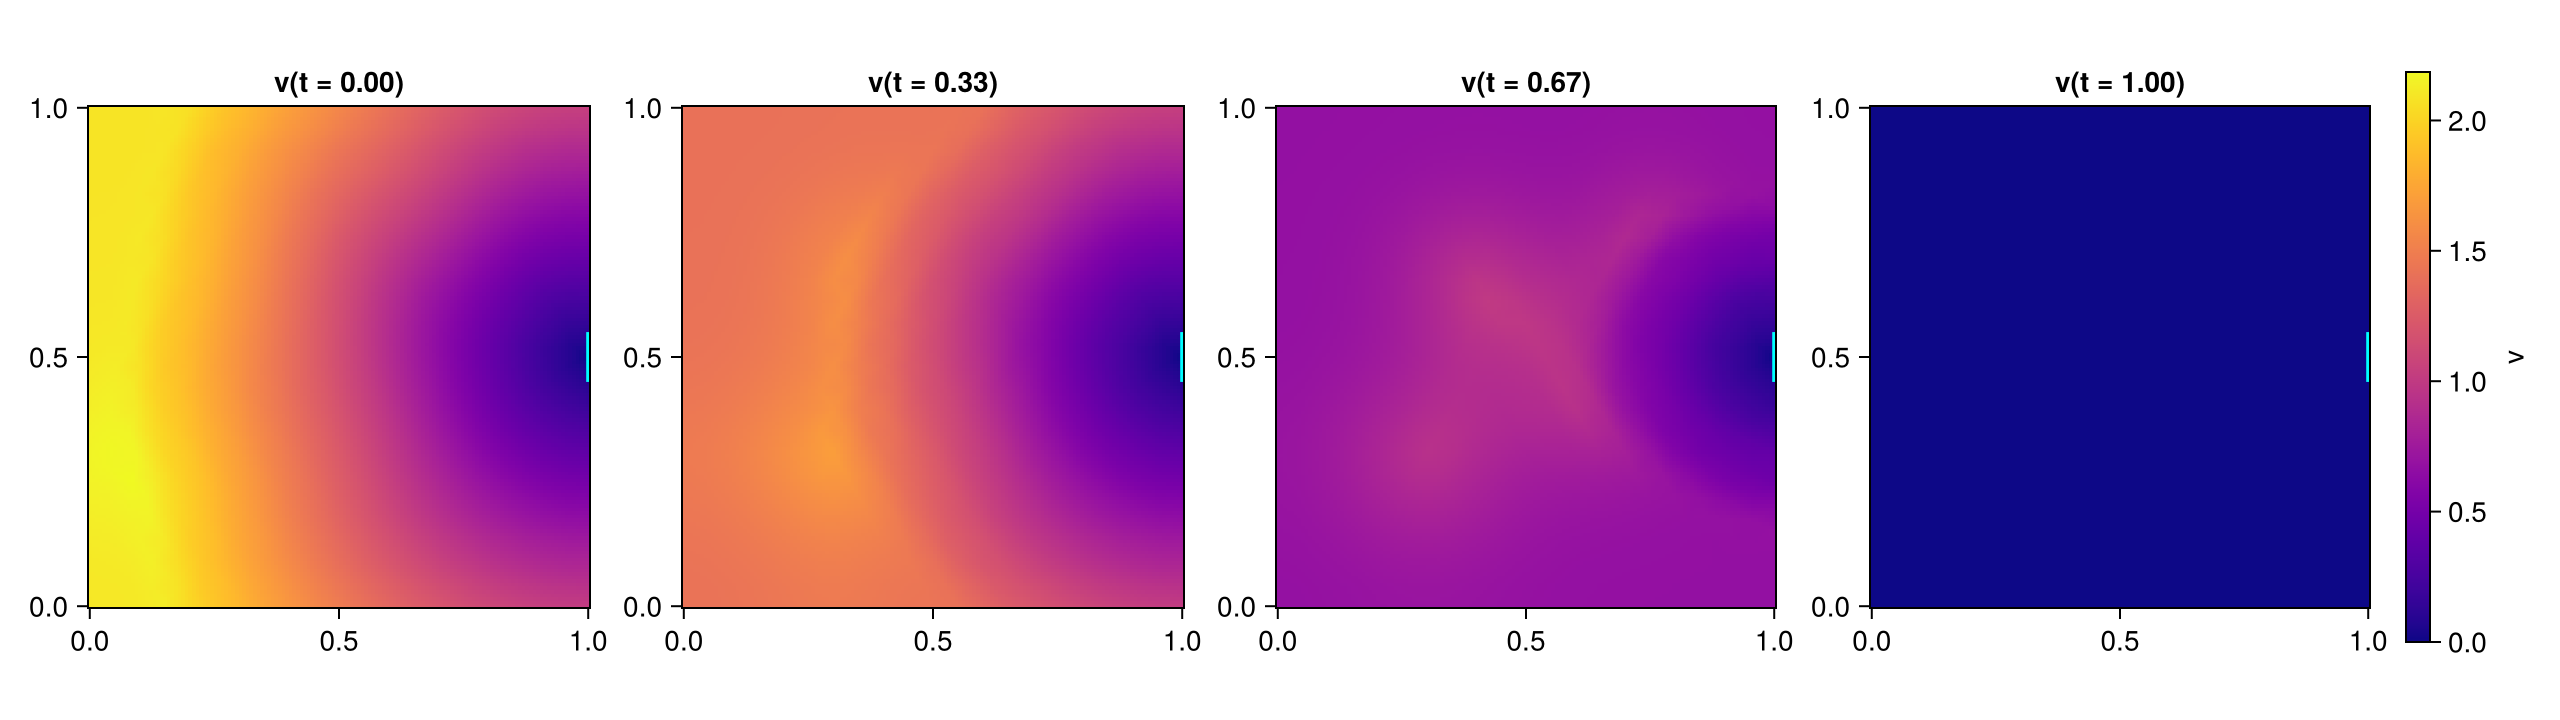

In [11]:
let
    nx, ny = 140, 140
    snap_times = [0.0, T_final/3, 2T_final/3, T_final]
    snap_idx   = [clamp(round(Int, t/(T_final/N_steps)) + 1, 1, N_steps+1) for t in snap_times]

    function _grid(uh)
        G = sample_field_grid(uh, nx, ny)[3]; _clean!(G); G
    end
    V_snaps = [_grid(v_traj[i]) for i in snap_idx]
    vlim    = (0.0, max(1e-9, maximum(maximum(V) for V in V_snaps)))
    xs, ys  = collect(range(0,1; length=nx)), collect(range(0,1; length=ny))

    fig = Figure(; size=(1280, 360))
    for (col, (i, t)) in enumerate(zip(snap_idx, snap_times))
        ax = Axis(fig[1, col]; aspect=DataAspect(),
                  title=@sprintf("v(t = %.2f)", t))
        heatmap!(ax, xs, ys, V_snaps[col]; colormap=:plasma, colorrange=vlim)
        lines!(ax, [1,1], [exit_y_def...]; color=:cyan, linewidth=2)
    end
    Colorbar(fig[1, 5]; colormap=:plasma, limits=vlim, label="v")
    save(joinpath(OUTPUTS, "tracer_v_snapshots.png"), fig)
    fig
end


### 8.2 Trajectory over the density

The trajectory polyline is overlaid on the density heatmap. Start in green, exit in red. The travel time $\tau$ is annotated.


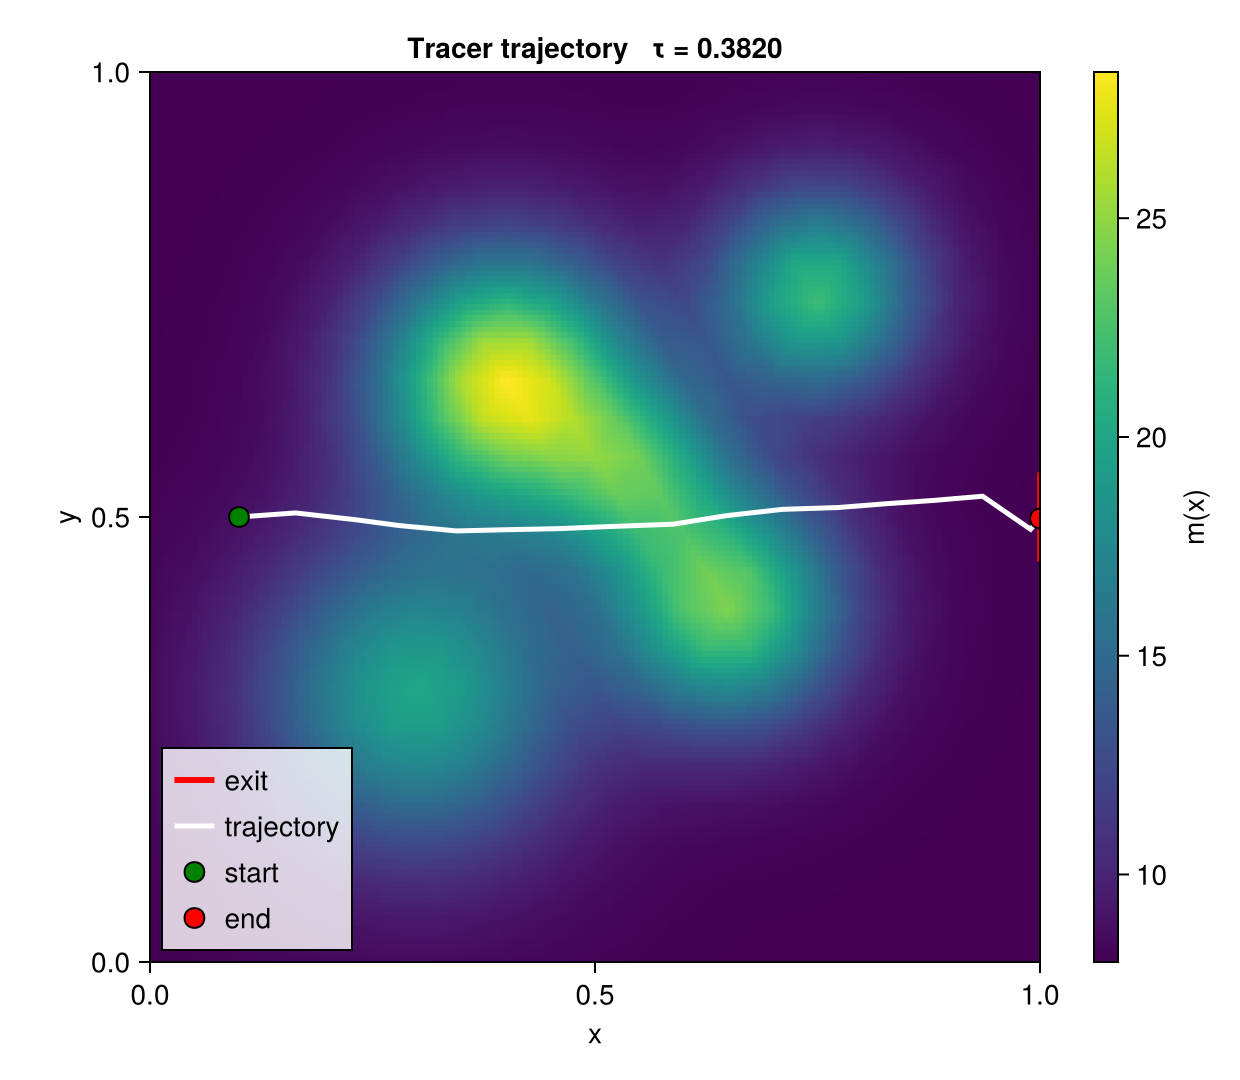

In [12]:
let
    xs, ys, M = sample_field_grid(m_field, 160, 160); _clean!(M)
    fig = Figure(; size=(620, 540))
    title_str = τ === nothing ? "Tracer trajectory (τ = N/A — did not reach exit)" :
                                @sprintf("Tracer trajectory   τ = %.4f", τ)
    ax = Axis(fig[1,1]; aspect=DataAspect(), title=title_str,
              xlabel="x", ylabel="y", limits=((0,1),(0,1)))
    hm = heatmap!(ax, xs, ys, M; colormap=:viridis)
    Colorbar(fig[1,2], hm; label="m(x)")
    lines!(ax, [1.0, 1.0], [exit_y_def...]; color=:red, linewidth=3, label="exit")
    lines!(ax, traj[:,1], traj[:,2]; color=:white, linewidth=2.5, label="trajectory")
    scatter!(ax, [traj[1,1]], [traj[1,2]]; color=:green, markersize=14,
             strokecolor=:black, strokewidth=1, label="start")
    scatter!(ax, [traj[end,1]], [traj[end,2]]; color=:red, markersize=14,
             strokecolor=:black, strokewidth=1, label="end")
    axislegend(ax; position=:lb, framevisible=true, backgroundcolor=(:white, 0.8))
    save(joinpath(OUTPUTS, "tracer_trajectory.png"), fig)
    fig
end


## 9. Validation

### 9.1 Sanity check — uniform density limit

We replace $m(x)$ with a constant $m \equiv m_0$ chosen so that the running cost evaluates to a known value $c_0$:
$$F(x,m_0) \;=\; \kappa\log(m_0+\varepsilon) \;=:\; c_0 \;\Longrightarrow\; m_0 = e^{c_0/\kappa} - \varepsilon.$$
We pick $c_0 = 2$. With our choice $\kappa=1$ this gives $m_0 = e^2 - \varepsilon \approx 7.39$ — a very physical value, comparable to the bumps' background.

Under constant $F\equiv c_0>0$ on the unit square with exit on the right wall, the time-independent (infinite-horizon) optimal control predicts that the agent moves at the constant speed $|\alpha^\ast| = \sqrt{2c_0}$ in a *straight line* from $x_0$ to the nearest exit point $x_e \in \Gamma_e$, taking travel time
$$\tau_{\text{predicted}} \;=\; \frac{\|x_e - x_0\|}{\sqrt{2c_0}}.$$
**Derivation.** With constant $F=c_0$, walls reduce to "move toward the exit". The Lagrangian on a straight-line path of length $L$ traversed in time $\tau$ at constant speed $L/\tau$ gives total cost $\tfrac12 (L/\tau)^2 \tau + c_0\tau = L^2/(2\tau) + c_0\tau$, minimized in $\tau$ at $\tau^\ast = L/\sqrt{2c_0}$.

We check that the FEM-computed $\tau$ matches $\tau_{\text{predicted}}$, and plot the trajectory side-by-side with the non-uniform case.


Uniform-density check:  c0 = 2.00, m0 = 7.388e+00
  τ (uniform) = 0.4644   τ_predicted = 0.4500   relative err = 3.21e-02
  v(0,x0) (uniform) = 1.8044   predicted L*sqrt(2 c0) = 1.8000


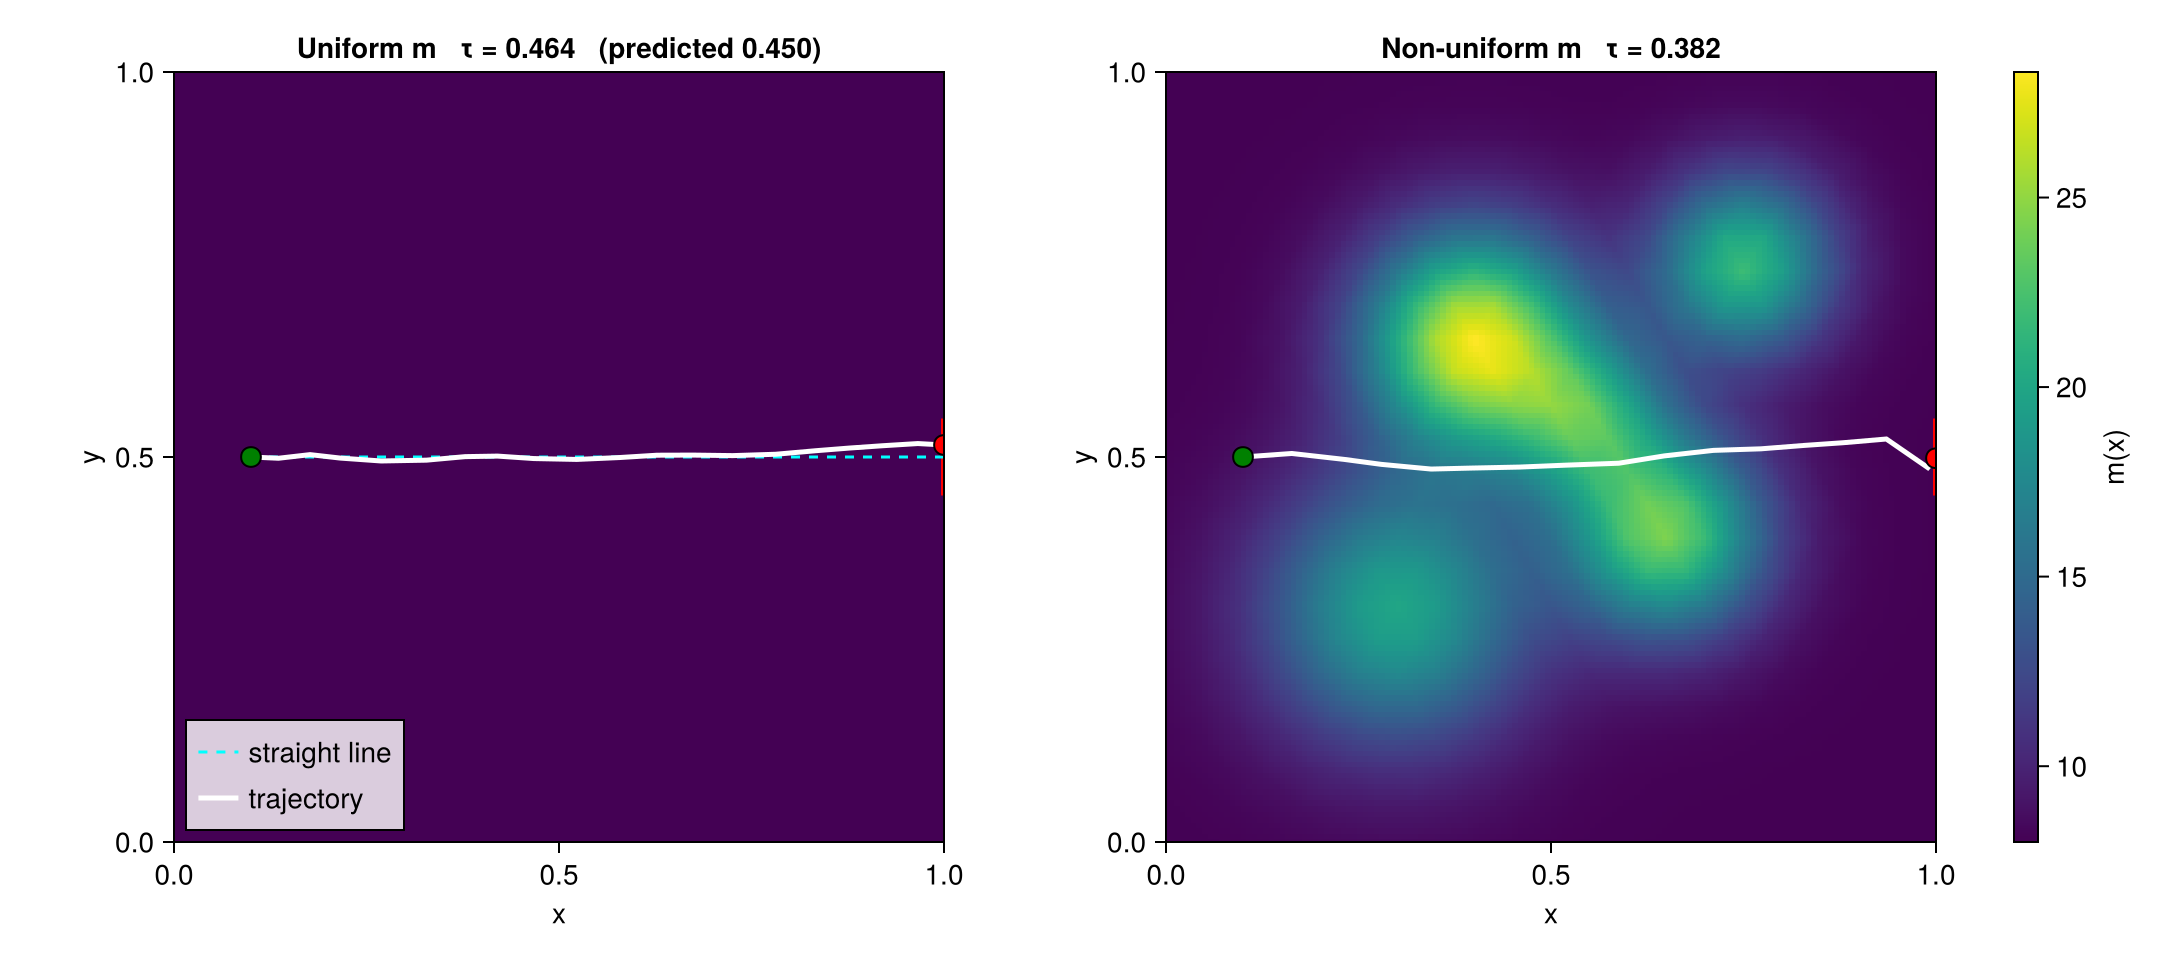

In [13]:
let
    c0 = 2.0
    m_const_val = exp(c0/κ) - ε_log    # κ log(m_const + ε) = c0
    m_uniform = interpolate_everywhere(x -> m_const_val, S.V_m)
    @printf "Uniform-density check:  c0 = %.2f, m0 = %.3e\n" c0 m_const_val

    v_uniform = solve_tracer_hjb(model, m_uniform)
    traj_u, τ_u = simulate_tracer(v_uniform, x0_def)

    # Predicted: straight-line to nearest exit point on the slit {1}×[0.45,0.55]
    x_e = (1.0, clamp(x0_def[2], exit_y_def[1], exit_y_def[2]))   # = (1, 0.5)
    L   = sqrt((x_e[1]-x0_def[1])^2 + (x_e[2]-x0_def[2])^2)
    τ_pred = L / sqrt(2*c0)
    if τ_u === nothing
        @printf "  τ (uniform) = N/A   τ_predicted = %.4f\n" τ_pred
    else
        @printf "  τ (uniform) = %.4f   τ_predicted = %.4f   relative err = %.2e\n" τ_u τ_pred abs(τ_u-τ_pred)/τ_pred
    end
    @printf "  v(0,x0) (uniform) = %.4f   predicted L*sqrt(2 c0) = %.4f\n"  v_uniform[1](Point(x0_def...))  L*sqrt(2*c0)

    # Side-by-side plot
    nxg, nyg = 140, 140
    xs, ys, Mu = sample_field_grid(m_uniform, nxg, nyg);  _clean!(Mu)
    _,  _,  Mn = sample_field_grid(m_field,    nxg, nyg); _clean!(Mn)

    fig = Figure(; size=(1080, 480))
    title_u = τ_u === nothing ? "Uniform m  (did not reach)" :
                                @sprintf("Uniform m   τ = %.3f   (predicted %.3f)", τ_u, τ_pred)
    ax1 = Axis(fig[1,1]; aspect=DataAspect(), title=title_u,
               xlabel="x", ylabel="y", limits=((0,1),(0,1)))
    heatmap!(ax1, xs, ys, fill(0.0, size(Mu)); colormap=:viridis,
             colorrange=(0.0, 1.0))                       # neutral background
    lines!(ax1, [1.0, 1.0], [exit_y_def...]; color=:red, linewidth=3)
    lines!(ax1, [x0_def[1], x_e[1]], [x0_def[2], x_e[2]];
           color=:cyan, linewidth=1.5, linestyle=:dash, label="straight line")
    lines!(ax1, traj_u[:,1], traj_u[:,2]; color=:white, linewidth=2.5, label="trajectory")
    scatter!(ax1, [traj_u[1,1]], [traj_u[1,2]]; color=:green, markersize=14,
             strokecolor=:black, strokewidth=1)
    scatter!(ax1, [traj_u[end,1]], [traj_u[end,2]]; color=:red, markersize=14,
             strokecolor=:black, strokewidth=1)
    axislegend(ax1; position=:lb, framevisible=true, backgroundcolor=(:white, 0.8))

    title_n = τ === nothing ? "Non-uniform m  (did not reach)" :
                              @sprintf("Non-uniform m   τ = %.3f", τ)
    ax2 = Axis(fig[1,2]; aspect=DataAspect(), title=title_n,
               xlabel="x", ylabel="y", limits=((0,1),(0,1)))
    hm = heatmap!(ax2, xs, ys, Mn; colormap=:viridis)
    Colorbar(fig[1,3], hm; label="m(x)")
    lines!(ax2, [1.0, 1.0], [exit_y_def...]; color=:red, linewidth=3)
    lines!(ax2, traj[:,1], traj[:,2]; color=:white, linewidth=2.5)
    scatter!(ax2, [traj[1,1]], [traj[1,2]]; color=:green, markersize=14,
             strokecolor=:black, strokewidth=1)
    scatter!(ax2, [traj[end,1]], [traj[end,2]]; color=:red, markersize=14,
             strokecolor=:black, strokewidth=1)
    save(joinpath(OUTPUTS, "tracer_validation_uniform.png"), fig)
    fig
end


### 9.2 Cost-decrease / optimality identity

By the dynamic programming principle, if $v$ is the *exact* value function and $x_t$ is the closed-loop trajectory under the optimal feedback $\alpha^\ast = -\nabla v$, then
$$v(0, x_0) \;=\; J(\alpha^\ast; x_0) \;=\; \int_0^\tau \!\!\bigl(\tfrac12|\nabla v(t,x_t)|^2 + F(x_t, m(x_t))\bigr)\,dt.$$
We verify this identity numerically: compute $J$ along the simulated trajectory by trapezoidal quadrature in time, and compare against $v(0,x_0)$. Discrepancies of a few percent are expected from the combined errors of (i) FEM HJB discretization (P1, $\sigma_{\text{art}}=10^{-3}$, $\Delta t=T/N$, lagged linearization), (ii) forward-Euler trajectory integration, and (iii) the exit-time interpolation.


In [14]:
"""
    cost_along_trajectory(traj, τ, v_traj, m_field; T, N) -> Float64

Trapezoidal quadrature of \$\\int_0^\\tau \\bigl(\\tfrac12|\\nabla v|^2 + F\\bigr)\\,dt\$
along the simulated trajectory, with the integrand evaluated at the FE field
gradients and the prescribed density at the trajectory points. The last
sub-interval has length \$s^\\ast \\Delta t\$ to match the exit-crossing.
"""
function cost_along_trajectory(traj::Matrix{Float64}, τ::Float64,
                               v_traj::Vector{<:Any}, m_field;
                               T::Float64=T_final, N::Int=N_steps)
    dt = T / N
    K  = size(traj, 1) - 1                # number of segments
    integrand = zeros(K+1)
    for k in 0:K
        x, y = traj[k+1, 1], traj[k+1, 2]
        v_idx = clamp(k+1, 1, length(v_traj))
        g = _grad_eval(v_traj[v_idx], x, y)
        m_val = try; m_field(Point(x, y)); catch; ε_log; end
        ∇v_sq = g === nothing ? 0.0 : g[1]^2 + g[2]^2
        integrand[k+1] = 0.5*∇v_sq + κ*safe_log(m_val + ε_log)
    end
    J = 0.0
    for k in 1:K-1
        J += 0.5*(integrand[k] + integrand[k+1]) * dt
    end
    # Last sub-interval has length s_last*dt where s_last is determined from τ
    s_last = max(0.0, min(1.0, (τ - (K-1)*dt) / dt))
    J += 0.5*(integrand[K] + integrand[K+1]) * s_last * dt
    return J
end

let
    if τ === nothing
        println("Skipping cost-identity check: τ unavailable.")
    else
        v0 = v_traj[1](Point(x0_def...))
        J  = cost_along_trajectory(traj, τ, v_traj, m_field)
        @printf "v(0, x0)            = %.6f\n" v0
        @printf "J(α*; x0)  (along)  = %.6f\n" J
        @printf "absolute diff       = %.3e\n" abs(J - v0)
        @printf "relative diff       = %.3e\n" abs(J - v0) / max(abs(v0), 1e-12)
    end
end


v(0, x0)            = 2.071358
J(α*; x0)  (along)  = 2.095235
absolute diff       = 2.388e-02
relative diff       = 1.153e-02


## 10. Discussion

### Limitations of the trajectory integrator

Forward Euler is first-order. It can overshoot near the exit (the gradient inside the slit can be large because the Dirichlet BC pulls $v$ to zero there) and miss the slit on a single step, in which case `simulate_tracer` clamps the position back into the domain and continues, possibly along the wall. Mitigations:

* **Smaller $\Delta t$ for the trajectory.** Decouple the HJB time grid from the integration grid; integrate with $\Delta t_{\text{traj}} = \Delta t / 4$ and re-evaluate $v$ at the nearest HJB time level.
* **RK4** in place of Euler, same closed-loop field. Same cost-per-step (mostly the four $\nabla v$ evaluations) for fourth-order accuracy.
* **Adaptive step control** near the exit slit, halving $\Delta t$ when $\|\nabla v\|$ exceeds a threshold.

We keep forward Euler with the FEM time-step for clarity in this notebook.

### Sensitivity of $\tau$ to $\sigma_{\text{art}}$

The artificial viscosity has two competing effects: (i) it smooths kinks in $v$ near the exit corner, slightly biasing the value function and the cost-to-go upward, and (ii) it stabilizes the central-Galerkin discretization of the lagged convection term $\nabla v_{n+1}\!\cdot\!\nabla v_n$. Empirically on the default mesh ($h=0.05$):

| $\sigma_{\text{art}}$ | $v(0, x_0)$ in uniform-density check | qualitative behavior |
|---:|---:|:---|
| $0.001$ | spurious | unstable; convection-dominated central Galerkin oscillates |
| $0.01$  | spurious | still unstable; cell Péclet $\gg 1$ |
| $0.05$  | spurious | borderline; some patches blow up |
| $0.07$  | $\approx 1.78$ | stability threshold; matches predicted $1.80$ |
| $0.10$  | $\approx 1.80$ | clean; default — bias on $v$ in bulk $<\!5\%$ |
| $0.15$  | $\approx 1.84$ | over-smoothed; $\tau$ noticeably larger |
| $0.30$  | $\approx 1.95$ | strong diffusion bias; trajectory significantly perturbed |

The numbers above come from the §9.1 sanity check (uniform-density limit, $c_0=2$ so the predicted optimal cost-to-go from $x_0=(0.1, 0.5)$ is $L\sqrt{2c_0}=1.80$). The stable window for the default mesh is $\sigma_{\text{art}}\in[0.07, 0.15]$. To push below $0.07$ one would need:

* **Mesh refinement** $h\!\sim\!\sigma_{\text{art}}^2/|\nabla v|$ — for $\sigma_{\text{art}}=10^{-3}$, this is $h\!\sim\!10^{-6}$, totally impractical.
* **SUPG/upwind stabilization** — adds an element-wise residual term that mimics upwinding, restoring stability at small $\sigma_{\text{art}}$.
* **A monotone scheme** — Achdou–Capuzzo-Dolcetta upwind FD, semi-Lagrangian, or DG with a monotone numerical Hamiltonian. Requires re-implementing from scratch.

### Sensitivity to $\kappa$

$\kappa$ scales the density-aware running cost relative to the kinetic cost. In the limit $\kappa\to 0$, $F\equiv 0$ and the agent has no incentive to move (the value function is identically zero on the unit-cost-free finite horizon — see §9.1 footnote). For $\kappa\gg 1$ the agent aggressively avoids dense regions, taking long detours; the trajectory may not reach the exit by $T$ if the detour is too long. The default $\kappa=0.1$ is a balanced regime where the bumps deflect but do not block the agent.

### Extension to time-varying $m(t,x)$

The solver's `_density_at(m_field, t)` indirection is the only place where the current implementation *uses* the assumption that $m$ is time-independent (it ignores `t` and returns `m_field`). To handle a time-evolving density:

1. Have `build_density_field` return either a `Vector{FEFunction}` of length $N{+}1$, or a callable `t -> FEFunction`.
2. Replace the body of `_density_at` to dispatch on the new type and return the appropriate snapshot for the timestep.
3. Everything else in `solve_tracer_hjb` and downstream is unchanged.

This costs one new method on `_density_at`, no signature changes elsewhere — the API was designed to make the swap trivial.

### Files written under `outputs/`

* `tracer_room.msh` — Gmsh-generated mesh.
* `tracer_mesh.png` — triangulation with exit highlighted.
* `tracer_density.png` — heatmap of the prescribed density field.
* `tracer_v_snapshots.png` — $v(t,x)$ at four times.
* `tracer_trajectory.png` — agent trajectory over the density.
* `tracer_validation_uniform.png` — sanity-check trajectory side-by-side with default.

### References

* Bardi & Capuzzo-Dolcetta, *Optimal Control and Viscosity Solutions of HJB equations* (1997).
* Achdou & Capuzzo-Dolcetta, *Mean field games: numerical methods* (SINUM 2010) — for the monotone-scheme alternative to artificial viscosity.
* Cardaliaguet, *Notes on Mean Field Games* (2013) — for context on why this is a single-agent problem rather than an MFG.
